# VLLM multi-GPU annotation (Gemma, 2 GPUs, parallel workers)

Optimisé pour l'utilisation de 4 GPUs, plusieurs workers et threads pour accélérer l'inférence sur un grand échantillon.

## 1) Runtime et configuration (multi-GPU, workers, threads)

In [23]:
import os
import json
import re
import shutil
import subprocess
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from vllm import LLM, SamplingParams

os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = '1'
os.environ["MKL_THREADING_LAYER"] = 'GNU'
os.environ["MKL_SERVICE_FORCE_INTEL"] = '1'

conda_prefix = os.environ.get("CONDA_PREFIX", "")
if conda_prefix:
    conda_lib = f'{conda_prefix}/lib'
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = f'{conda_lib}:{ld_library_path}' if ld_library_path else conda_lib

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('/home/cbenavent/test/Arcom_rares')

DATASET_PATH = PROJECT_ROOT / 'data' / 'annotation_working_master_human_2100_seed.csv'
OUTPUT_DIR = PROJECT_ROOT / 'communication_function_outputs' / 'multi_gpu_vllm_test'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'google/gemma-4-26B-A4B'
MAX_NEW_TOKENS = 600
GEMMA_MAX_MODEL_LEN = 32768
VLLM_SWAP_SPACE_GB = 8
SAMPLE_SIZE = None

def detect_gpu_configuration(max_gpus: int = 4, min_free_gb: float = 35.0):
    query = [
        "nvidia-smi",
        "--query-gpu=index,memory.total,memory.free,name",
        "--format=csv,noheader,nounits",
    ]
    try:
        completed = subprocess.run(query, check=True, capture_output=True, text=True)
    except Exception as exc:
        raise RuntimeError(f"Unable to query GPUs with nvidia-smi: {exc}") from exc

    gpu_stats = []
    for line in completed.stdout.strip().splitlines():
        parts = [part.strip() for part in line.split(",", 3)]
        if len(parts) < 4:
            continue
        gpu_index, total_mem, free_mem, gpu_name = parts
        total_gb = float(total_mem) / 1024.0
        free_gb = float(free_mem) / 1024.0
        gpu_stats.append({
            "index": gpu_index,
            "name": gpu_name,
            "total_gb": total_gb,
            "free_gb": free_gb,
            "free_ratio": free_gb / total_gb if total_gb else 0.0,
        })

    gpu_stats.sort(key=lambda item: item["free_gb"], reverse=True)
    eligible = [gpu for gpu in gpu_stats if gpu["free_gb"] >= min_free_gb][:max_gpus]
    supported_tp_sizes = [4, 2, 1]
    tp_size = next((size for size in supported_tp_sizes if size <= len(eligible)), 0)
    if tp_size == 0:
        raise RuntimeError(
            f"Not enough free GPUs for vLLM. Found {len(eligible)} GPU(s) with at least {min_free_gb} GiB free."
        )

    selected = eligible[:tp_size]
    min_free_ratio = min(gpu["free_ratio"] for gpu in selected)
    gpu_memory_utilization = min(0.50, max(0.30, round(min_free_ratio - 0.03, 2)))
    return gpu_stats, selected, tp_size, gpu_memory_utilization

GPU_STATS, SELECTED_GPUS, TENSOR_PARALLEL_SIZE, VLLM_GPU_MEMORY_UTILIZATION = detect_gpu_configuration()
CUDA_VISIBLE_DEVICES = ",".join(gpu["index"] for gpu in SELECTED_GPUS)
os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

disk = shutil.disk_usage(PROJECT_ROOT)
disk_free_gb = disk.free / (1024**3)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_PATH exists:', DATASET_PATH.exists())
print('Model:', MODEL_NAME)
print('All GPU stats:', GPU_STATS)
print('Selected GPUs:', SELECTED_GPUS)
print('TENSOR_PARALLEL_SIZE:', TENSOR_PARALLEL_SIZE)
print('SAMPLE_SIZE:', 'ALL' if SAMPLE_SIZE is None else SAMPLE_SIZE)
print('VLLM_GPU_MEMORY_UTILIZATION:', VLLM_GPU_MEMORY_UTILIZATION)
print('GEMMA_MAX_MODEL_LEN:', GEMMA_MAX_MODEL_LEN)
print('VLLM_SWAP_SPACE_GB:', VLLM_SWAP_SPACE_GB)
print(f'Disk free near PROJECT_ROOT: {disk_free_gb:.1f} GB')
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))

try:
    import torch
    if torch.cuda.is_available():
        print('GPUs:', torch.cuda.device_count(), [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
except Exception as exc:
    print('GPU check skipped:', exc)

PROJECT_ROOT: /home/cbenavent/test/Arcom_rares
DATASET_PATH exists: True
Model: google/gemma-4-26B-A4B
All GPU stats: [{'index': '2', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 43.4521484375, 'free_ratio': 0.46431180214963996}, {'index': '1', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 43.3896484375, 'free_ratio': 0.463643952833142}, {'index': '3', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 43.3896484375, 'free_ratio': 0.463643952833142}, {'index': '0', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 0.001953125, 'free_ratio': 2.0870291140561412e-05}]
Selected GPUs: [{'index': '2', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 43.4521484375, 'free_ratio': 0.46431180214963996}, {'index': '1', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 43.3896484375, 'free_ratio': 0.463643952833142}]
TENSOR_PARALLEL_SIZE: 2
SAMPLE_SIZE: ALL
VLLM_GPU_MEMORY_UTILIZATION: 0.43
GEMMA_MAX_MODEL

In [24]:
# --- Prompt et parsing ---
RUBRIC_TEXT = """You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
- phatic: social bond, closeness, relationship-maintaining language.

Rules:
- Score each dimension independently from 1 to 5.
- If highest score is tied, dominant_dimension must be mixed.
- dominant_dimension_score must equal the highest score.
- Keep reason short and concrete.
"""

DIMENSIONS = ["informativeness", "expressiveness", "phatic"]
SCORE_MIN = 1
SCORE_MAX = 5

def output_schema_text() -> str:
    return """Return strict JSON only with:
{
  \"informativeness\": 1,
  \"expressiveness\": 1,
  \"phatic\": 1,
  \"dominant_dimension\": \"informativeness|expressiveness|phatic|mixed\",
  \"dominant_dimension_score\": 1,
  \"confidence\": 0.0,
  \"alternative_dimension\": \"informativeness|expressiveness|phatic|mixed|\",
  \"reason\": \"short explanation\"
}
"""

GEMMA_CHAT_TEMPLATE = "<bos><start_of_turn>user\n{content}<end_of_turn>\n<start_of_turn>model\n"

def build_prompt(visuel: str) -> str:
    clean_visuel = " ".join(str(visuel).split()).strip()
    content = (
        f"{RUBRIC_TEXT}\n\n"
        f"{output_schema_text()}\n\n"
        "Ad to score:\n"
        f"Visuel: {clean_visuel}\n\n"
        "Return only strict JSON."
    )
    return GEMMA_CHAT_TEMPLATE.format(content=content)

def clamp_score(value, default=1):
    try:
        score = float(value)
        if not SCORE_MIN <= score <= SCORE_MAX:
            raise ValueError(f"Score {score} out of bounds")
        return int(round(score))
    except Exception:
        return default

def normalize_dimension_name(value):
    text = str(value or "").strip().lower()
    aliases = {
        "informative": "informativeness",
        "information": "informativeness",
        "referential": "informativeness",
        "expressive": "expressiveness",
        "emotive": "expressiveness",
        "emotion": "expressiveness",
        "phatique": "phatic",
    }
    text = aliases.get(text, text)
    return text if text in DIMENSIONS or text == "mixed" else ""

def extract_json_object(text: str) -> dict:
    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL)
    candidates = [fenced.group(1)] if fenced else []
    candidates.append(text)
    decoder = json.JSONDecoder()
    for candidate in candidates:
        for match in re.finditer(r"\{", candidate):
            try:
                payload, _ = decoder.raw_decode(candidate[match.start():].strip())
                if isinstance(payload, dict):
                    return payload
            except json.JSONDecodeError:
                continue
    raise ValueError("Could not extract JSON from model output.")

def infer_scores_from_text(text: str) -> dict:
    labels = {
        "informativeness": ["informativeness", "informative", "referential", "information"],
        "expressiveness": ["expressiveness", "expressive", "emotive", "emotion"],
        "phatic": ["phatic", "phatique"],
    }
    compact = " ".join(str(text).split())
    extracted = {}
    for target, aliases in labels.items():
        score = None
        for alias in aliases:
            patterns = [
                rf"{alias}[^0-9]{{0,20}}([1-5])",
                rf"\"{alias}\"\s*:\s*([1-5])",
                rf"{alias}\s*=\s*([1-5])",
            ]
            for pattern in patterns:
                match = re.search(pattern, compact, flags=re.IGNORECASE)
                if match:
                    score = clamp_score(match.group(1))
                    break
            if score is not None:
                break
        extracted[target] = score if score is not None else 1
    return extracted

def coerce_prediction_dict(payload: dict, raw_text: str) -> dict:
    fallback_scores = infer_scores_from_text(raw_text)
    scores = {
        "informativeness": clamp_score(payload.get("informativeness", fallback_scores["informativeness"])),
        "expressiveness": clamp_score(payload.get("expressiveness", fallback_scores["expressiveness"])),
        "phatic": clamp_score(payload.get("phatic", fallback_scores["phatic"])),
    }
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_score = ranked[0][1]
    top_labels = [k for k, v in ranked if v == top_score]
    inferred_dom = "mixed" if len(top_labels) > 1 else top_labels[0]
    inferred_alt = ranked[1][0] if len(ranked) > 1 else ""
    dominant_dimension = normalize_dimension_name(payload.get("dominant_dimension")) or inferred_dom
    dominant_dimension_score = top_score
    alternative_dimension = normalize_dimension_name(payload.get("alternative_dimension")) or inferred_alt
    try:
        confidence = round(float(payload.get("confidence", 0.5)), 4)
    except Exception:
        confidence = 0.5
    confidence = max(0.0, min(1.0, confidence))
    reason = " ".join(str(payload.get("reason", "")).split()).strip()
    if not reason:
        reason = "parsed with fallback"
    return {
        "informativeness": scores["informativeness"],
        "expressiveness": scores["expressiveness"],
        "phatic": scores["phatic"],
        "dominant_dimension": dominant_dimension,
        "dominant_dimension_score": dominant_dimension_score,
        "confidence": confidence,
        "alternative_dimension": alternative_dimension,
        "reason": reason,
    }

def parse_model_prediction(raw_text: str):
    try:
        payload = extract_json_object(raw_text)
        prediction = coerce_prediction_dict(payload, raw_text)
        return prediction, True, ""
    except Exception as exc:
        prediction = coerce_prediction_dict({}, raw_text)
        return prediction, False, str(exc)

In [25]:
# --- Chargement et nettoyage — ensemble du fichier ---
df = pd.read_csv(DATASET_PATH)
if "Visuel" not in df.columns:
    raise ValueError("Column 'Visuel' not found in dataset.")

def clean_visuel_text(value: str) -> str:
    text = "" if pd.isna(value) else str(value)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Toutes les lignes avec Visuel non-null
sample_df = df.loc[df["Visuel"].notna(), ["row_id", "Visuel"]].copy()
sample_df.rename(columns={"Visuel": "visuel"}, inplace=True)
sample_df["visuel"] = sample_df["visuel"].apply(clean_visuel_text)
if SAMPLE_SIZE is not None:
    sample_df = sample_df.head(SAMPLE_SIZE).copy()
print(f"Nombre de lignes à annoter (sample): {len(sample_df)}")
sample_df.head()


Nombre de lignes à annoter (sample): 8938


,row_id,visuel
0,0,"En caméra cachée, un homme invite des personne..."
1,1,Un homme recharge sa NISSAN LEAF et traverse u...
2,2,Des journalistes interrogent un homme qui vien...
3,3,Des journalistes interrogent un homme qui vien...
4,4,Des journalistes interrogent un homme qui vien...


In [26]:
# --- Helpers de generation ---
sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=MAX_NEW_TOKENS,
    stop=["<end_of_turn>"]
 )

def default_prediction(reason: str, parse_ok: bool = False) -> dict:
    # Do not masquerade engine failures as valid low scores.
    return {
        "prediction": {
            "informativeness": None,
            "expressiveness": None,
            "phatic": None,
            "dominant_dimension": "",
            "dominant_dimension_score": None,
            "confidence": 0.0,
            "alternative_dimension": "",
            "reason": reason,
        },
        "parse_ok": parse_ok,
        "parse_error": "" if parse_ok else reason,
    }

In [27]:
# Validation rapide du fallback en cas d'echec moteur
print("This cell is only a fallback demo. It does NOT run the model.")
print("Expected result here: parse_ok=False and scores=None.")
display(pd.DataFrame([default_prediction("engine failure test")]))
display(pd.DataFrame([(default_prediction("engine failure test")["prediction"])]))

This cell is only a fallback demo. It does NOT run the model.
Expected result here: parse_ok=False and scores=None.


,prediction,parse_ok,parse_error
0,"{'informativeness': None, 'expressiveness': No...",False,engine failure test


,informativeness,expressiveness,phatic,dominant_dimension,dominant_dimension_score,confidence,alternative_dimension,reason
0,None,None,None,,None,0.0,,engine failure test


In [28]:
# Probe vLLM: capturer l'erreur d'initialisation complete
import traceback

llm_probe = None
try:
    llm_probe = LLM(
        model=MODEL_NAME,
        tensor_parallel_size=TENSOR_PARALLEL_SIZE,
        trust_remote_code=True,
        gpu_memory_utilization=VLLM_GPU_MEMORY_UTILIZATION,
        max_model_len=GEMMA_MAX_MODEL_LEN,
        disable_custom_all_reduce=True,
        dtype='bfloat16',
    )
    print("vLLM init OK")
except Exception as exc:
    print(type(exc).__name__)
    print(str(exc))
    print(traceback.format_exc())
finally:
    try:
        if llm_probe is not None:
            del llm_probe
        import gc; gc.collect()
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass

INFO 05-20 12:41:46 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 32768, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.43, 'disable_log_stats': True, 'disable_custom_all_reduce': True, 'model': 'google/gemma-4-26B-A4B'}
INFO 05-20 12:41:46 [model.py:549] Resolved architecture: Gemma4ForConditionalGeneration
INFO 05-20 12:41:46 [model.py:1678] Using max model len 32768
INFO 05-20 12:41:46 [config.py:104] Gemma4 model has heterogeneous head dimensions (head_dim=256, global_head_dim=512). Forcing TRITON_ATTN backend to prevent mixed-backend numerical divergence.


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(EngineCore pid=2048645) INFO 05-20 12:41:55 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='google/gemma-4-26B-A4B', speculative_config=None, tokenizer='google/gemma-4-26B-A4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detai

/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(Worker pid=2048805) INFO 05-20 12:42:06 [parallel_state.py:1400] world_size=2 rank=0 local_rank=0 distributed_init_method=tcp://127.0.0.1:37993 backend=nccl
(Worker pid=2048806) INFO 05-20 12:42:06 [parallel_state.py:1400] world_size=2 rank=1 local_rank=1 distributed_init_method=tcp://127.0.0.1:37993 backend=nccl


...

(Worker_TP0 pid=2048805) INFO 05-20 12:43:36 [gpu_model_runner.py:6046] Graph capturing finished in 36 secs, took 1.38 GiB
(Worker_TP0 pid=2048805) INFO 05-20 12:43:36 [gpu_worker.py:597] CUDA graph pool memory: 1.38 GiB (actual), 1.38 GiB (estimated), difference: 0.01 GiB (0.4%).
(Worker_TP1 pid=2048806) INFO 05-20 12:43:37 [gpu_worker.py:597] CUDA graph pool memory: 1.38 GiB (actual), 1.38 GiB (estimated), difference: 0.01 GiB (0.4%).
(EngineCore pid=2048645) INFO 05-20 12:43:37 [core.py:283] init engine (profile, create kv cache, warmup model) took 77.33 seconds


(EngineCore pid=2048645) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


(EngineCore pid=2048645) INFO 05-20 12:43:42 [vllm.py:790] Asynchronous scheduling is enabled.


(EngineCore pid=2048645) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2048645) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=2048645) INFO 05-20 12:43:43 [compilation.py:292] Enabled custom fusions: allreduce_rms
vLLM init OK
(EngineCore pid=2048645) INFO 05-20 12:43:43 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2048645) INFO 05-20 12:43:43 [core.py:1233] Shutdown complete
(Worker_TP0 pid=2048805) INFO 05-20 12:43:43 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP1 pid=2048806) INFO 05-20 12:43:43 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP0 pid=2048805) INFO 05-20 12:43:43 [multiproc_executor.py:859] WorkerProc shutting down.


In [29]:
# --- Inference : un seul LLM sur les GPUs disponibles, tous les prompts en un seul batch ---

def run_gemma_batch(sample: pd.DataFrame) -> list:
    """
    vLLM avec tensor_parallel_size adapte aux GPUs disponibles.
    On utilise llm.generate() avec les prompts deja formates au format chat Gemma
    (<bos><start_of_turn>user ... <end_of_turn><start_of_turn>model).
    """
    llm = None
    rows = []
    try:
        llm = LLM(
            model=MODEL_NAME,
            tensor_parallel_size=TENSOR_PARALLEL_SIZE,
            trust_remote_code=True,
            gpu_memory_utilization=VLLM_GPU_MEMORY_UTILIZATION,
            max_model_len=GEMMA_MAX_MODEL_LEN,
            disable_custom_all_reduce=True,
            dtype='bfloat16',
        )

        prompts = [build_prompt(v) for v in sample["visuel"].tolist()]
        print(f"Generation de {len(prompts)} reponses en batch ({TENSOR_PARALLEL_SIZE} GPUs)...")
        print(f"Exemple prompt (premiers 300 chars):\n{prompts[0][:300]}\n")

        try:
            outs = llm.generate(prompts, sampling_params, use_tqdm=True)
        except TypeError:
            outs = llm.generate(prompts, sampling_params)

        for in_row, out in zip(sample.itertuples(index=False), outs):
            raw_text = out.outputs[0].text if out.outputs else ""
            prediction, parse_ok, parse_error = parse_model_prediction(raw_text)
            rows.append({
                "row_id": int(getattr(in_row, "row_id")) if pd.notna(getattr(in_row, "row_id")) else None,
                "visuel": getattr(in_row, "visuel", ""),
                "model_name": MODEL_NAME,
                "raw_output": raw_text,
                "prediction": prediction,
                "parse_ok": parse_ok,
                "parse_error": parse_error,
            })

    except Exception as exc:
        error_text = f"LLM failed: {exc}"
        print(f"[ERROR] {error_text}")
        for in_row in sample.itertuples(index=False):
            rows.append({
                "row_id": int(getattr(in_row, "row_id")) if pd.notna(getattr(in_row, "row_id")) else None,
                "visuel": getattr(in_row, "visuel", ""),
                "model_name": MODEL_NAME,
                "raw_output": "",
                **default_prediction(reason=error_text, parse_ok=False),
            })
    finally:
        try:
            if llm is not None:
                del llm
            import gc; gc.collect()
            import torch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
        except Exception:
            pass

    return rows

In [30]:
# Smoke test: executer 3 exemples reels pour verifier les scores
mini_sample_df = sample_df.head(3).copy()
mini_results = run_gemma_batch(mini_sample_df)

mini_diag_df = pd.DataFrame([
    {
        "row_id": item.get("row_id"),
        "parse_ok": item.get("parse_ok"),
        "parse_error": item.get("parse_error"),
        "raw_output_preview": str(item.get("raw_output", ""))[:200],
        **(item.get("prediction") or {}),
    }
    for item in mini_results
])

display(mini_diag_df)

INFO 05-20 12:43:48 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 32768, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.43, 'disable_log_stats': True, 'disable_custom_all_reduce': True, 'model': 'google/gemma-4-26B-A4B'}
INFO 05-20 12:43:49 [model.py:549] Resolved architecture: Gemma4ForConditionalGeneration
INFO 05-20 12:43:49 [model.py:1678] Using max model len 32768
INFO 05-20 12:43:49 [config.py:104] Gemma4 model has heterogeneous head dimensions (head_dim=256, global_head_dim=512). Forcing TRITON_ATTN backend to prevent mixed-backend numerical divergence.


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(EngineCore pid=2049749) INFO 05-20 12:43:57 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='google/gemma-4-26B-A4B', speculative_config=None, tokenizer='google/gemma-4-26B-A4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detai

/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(Worker pid=2049909) INFO 05-20 12:44:08 [parallel_state.py:1400] world_size=2 rank=0 local_rank=0 distributed_init_method=tcp://127.0.0.1:38883 backend=nccl
(Worker pid=2049910) INFO 05-20 12:44:08 [parallel_state.py:1400] world_size=2 rank=1 local_rank=1 distributed_init_method=tcp://127.0.0.1:38883 backend=nccl


...

(EngineCore pid=2049749) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2049749) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=2049749) INFO 05-20 12:45:41 [compilation.py:292] Enabled custom fusions: allreduce_rms
Generation de 3 reponses en batch (2 GPUs)...
Exemple prompt (premiers 300 chars):
<bos><start_of_turn>user
You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
- phatic: social bond, closeness, relationship-maintaining language.

Rules:
- Score each d



Processed prompts: 100%|██████████| 3/3 [00:03<00:00,  1.04s/it, est. speed input: 302.68 toks/s, output: 105.18 toks/s]


(EngineCore pid=2049749) INFO 05-20 12:45:44 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2049749) INFO 05-20 12:45:44 [core.py:1233] Shutdown complete
(Worker_TP0 pid=2049909) INFO 05-20 12:45:44 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP1 pid=2049910) INFO 05-20 12:45:44 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP0 pid=2049909) INFO 05-20 12:45:44 [multiproc_executor.py:859] WorkerProc shutting down.


,row_id,parse_ok,parse_error,raw_output_preview,informativeness,expressiveness,phatic,dominant_dimension,dominant_dimension_score,confidence,alternative_dimension,reason
0,0,True,,"{\n ""informativeness"": 1,\n ""expressiveness""...",1,5,1,expressiveness,5,0.9,mixed,The ad focuses on creating a fun and surprisin...
1,1,True,,"{\n ""informativeness"": 3,\n ""expressiveness""...",3,4,2,expressiveness,4,0.8,informativeness,The ad focuses on the emotional impact of the ...
2,2,True,,"{\n ""informativeness"": 1,\n ""expressiveness""...",1,5,1,expressiveness,5,0.9,informativeness,The ad focuses on the emotional reaction of th...


In [31]:
# --- Execution et export — ensemble du fichier ---
import time

n = len(sample_df)
print(f"Running: {MODEL_NAME} (tensor_parallel_size={TENSOR_PARALLEL_SIZE}, n={n})")

perf_start_ts = time.perf_counter()
all_results = run_gemma_batch(sample_df)
perf_end_ts = time.perf_counter()

perf_total_seconds = max(0.0, perf_end_ts - perf_start_ts)
perf_items_per_second = (len(all_results) / perf_total_seconds) if perf_total_seconds > 0 else float("inf")

results_df = pd.DataFrame(all_results)

jsonl_path = OUTPUT_DIR / f"vllm_multi_gpu_predictions_full_{n}.jsonl"
csv_full_path = OUTPUT_DIR / f"vllm_multi_gpu_predictions_full_{n}_full.csv"
csv_scores_path = OUTPUT_DIR / f"vllm_multi_gpu_predictions_full_{n}_scores.csv"

with open(jsonl_path, "w", encoding="utf-8") as f:
    for item in all_results:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

flat_df = results_df.copy()
flat_df["prediction"] = flat_df["prediction"].apply(lambda x: json.dumps(x, ensure_ascii=False))
flat_df.to_csv(csv_full_path, index=False)

scores_df = pd.DataFrame([
    {
        "row_id": item.get("row_id"),
        "visuel": item.get("visuel", ""),
        "informativeness": (item.get("prediction") or {}).get("informativeness"),
        "expressiveness": (item.get("prediction") or {}).get("expressiveness"),
        "phatic": (item.get("prediction") or {}).get("phatic"),
        "model_name": item.get("model_name", ""),
    }
    for item in all_results
])
scores_df.to_csv(csv_scores_path, index=False)

print("Saved JSONL:", jsonl_path)
print("Saved full CSV:", csv_full_path)
print("Saved scores CSV:", csv_scores_path)
print(f"Inference time: {perf_total_seconds:.2f}s | Throughput: {perf_items_per_second:.2f} items/s")
scores_df.head(20)


Running: google/gemma-4-26B-A4B (tensor_parallel_size=2, n=8938)
INFO 05-20 12:45:49 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 32768, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.43, 'disable_log_stats': True, 'disable_custom_all_reduce': True, 'model': 'google/gemma-4-26B-A4B'}
INFO 05-20 12:45:50 [model.py:549] Resolved architecture: Gemma4ForConditionalGeneration
INFO 05-20 12:45:50 [model.py:1678] Using max model len 32768
INFO 05-20 12:45:50 [config.py:104] Gemma4 model has heterogeneous head dimensions (head_dim=256, global_head_dim=512). Forcing TRITON_ATTN backend to prevent mixed-backend numerical divergence.


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(EngineCore pid=2050872) INFO 05-20 12:45:58 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='google/gemma-4-26B-A4B', speculative_config=None, tokenizer='google/gemma-4-26B-A4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detai

/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(Worker pid=2051032) INFO 05-20 12:46:09 [parallel_state.py:1400] world_size=2 rank=0 local_rank=0 distributed_init_method=tcp://127.0.0.1:54633 backend=nccl
(Worker pid=2051033) INFO 05-20 12:46:09 [parallel_state.py:1400] world_size=2 rank=1 local_rank=1 distributed_init_method=tcp://127.0.0.1:54633 backend=nccl


...

(EngineCore pid=2050872) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2050872) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=2050872) INFO 05-20 12:47:45 [compilation.py:292] Enabled custom fusions: allreduce_rms
Generation de 8938 reponses en batch (2 GPUs)...
Exemple prompt (premiers 300 chars):
<bos><start_of_turn>user
You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
- phatic: social bond, closeness, relationship-maintaining language.

Rules:
- Score each d



Processed prompts: 100%|██████████| 8938/8938 [04:26<00:00, 33.52it/s, est. speed input: 10770.87 toks/s, output: 3828.04 toks/s] 


(EngineCore pid=2050872) INFO 05-20 12:52:16 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2050872) INFO 05-20 12:52:16 [core.py:1233] Shutdown complete
(Worker_TP0 pid=2051032) INFO 05-20 12:52:16 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP1 pid=2051033) INFO 05-20 12:52:16 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP0 pid=2051032) INFO 05-20 12:52:16 [multiproc_executor.py:859] WorkerProc shutting down.
Saved JSONL: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_predictions_full_8938.jsonl
Saved full CSV: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_predictions_full_8938_full.csv
Saved scores CSV: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_predictions_full_8938_scores.csv
Inference time: 392.42s | Throughput: 22.78 items/s


,row_id,visuel,informativeness,expressiveness,phatic,model_name
0,0,"En caméra cachée, un homme invite des personne...",1,5,1,google/gemma-4-26B-A4B
1,1,Un homme recharge sa NISSAN LEAF et traverse u...,3,4,2,google/gemma-4-26B-A4B
2,2,Des journalistes interrogent un homme qui vien...,1,5,1,google/gemma-4-26B-A4B
3,3,Des journalistes interrogent un homme qui vien...,1,5,1,google/gemma-4-26B-A4B
4,4,Des journalistes interrogent un homme qui vien...,1,5,1,google/gemma-4-26B-A4B
5,5,FORD B-MAX > Easy access**. **Portes arrière c...,4,2,1,google/gemma-4-26B-A4B
6,6,"Dans un restaurant, un homme et une femme inco...",1,5,1,google/gemma-4-26B-A4B
7,7,"Dans les gradins d'un court de tennis, une fem...",1,5,1,google/gemma-4-26B-A4B
8,8,Vision du monde en 2050 où les nouvelles techn...,1,5,1,google/gemma-4-26B-A4B
9,9,Vision du monde en 2050 où les nouvelles techn...,1,5,1,google/gemma-4-26B-A4B


In [32]:
# Diagnostic rapide: verifier si le modele renvoie du JSON exploitable
import pandas as pd

diag_rows = []
for item in all_results[:10]:
    pred = item.get("prediction") or {}
    diag_rows.append({
        "row_id": item.get("row_id"),
        "parse_ok": item.get("parse_ok"),
        "parse_error": str(item.get("parse_error", ""))[:120],
        "informativeness": pred.get("informativeness"),
        "expressiveness": pred.get("expressiveness"),
        "phatic": pred.get("phatic"),
        "raw_output_preview": str(item.get("raw_output", ""))[:300],
    })

diag_df = pd.DataFrame(diag_rows)
display(diag_df)
print("Parse OK rate:", sum(bool(x.get("parse_ok")) for x in all_results), "/", len(all_results))

,row_id,parse_ok,parse_error,informativeness,expressiveness,phatic,raw_output_preview
0,0,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
1,1,True,,3,4,2,"{\n ""informativeness"": 3,\n ""expressiveness""..."
2,2,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
3,3,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
4,4,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
5,5,True,,4,2,1,"{\n ""informativeness"": 4,\n ""expressiveness""..."
6,6,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
7,7,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
8,8,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."
9,9,True,,1,5,1,"{\n ""informativeness"": 1,\n ""expressiveness""..."


Parse OK rate: 8938 / 8938


In [33]:
# --- Performance summary + export CSV ---
# Requiert l'execution de la cellule precedente.

from datetime import datetime, timezone

if "all_results" not in globals() or "perf_total_seconds" not in globals():
    raise RuntimeError("Execute d'abord la cellule d'execution pour calculer les metriques de performance.")

n_items = len(all_results)
parse_ok_count = int(sum(1 for item in all_results if bool(item.get("parse_ok", False))))
parse_fail_count = n_items - parse_ok_count
parse_ok_rate = (parse_ok_count / n_items * 100.0) if n_items > 0 else 0.0
avg_latency_ms_per_item = (perf_total_seconds / n_items * 1000.0) if n_items > 0 else 0.0

run_ts_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")

perf_row = {
    "run_ts_utc": run_ts_utc,
    "model_name": MODEL_NAME,
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "items_processed": n_items,
    "total_time_seconds": round(perf_total_seconds, 3),
    "throughput_items_per_second": round(perf_items_per_second, 3),
    "avg_latency_ms_per_item": round(avg_latency_ms_per_item, 3),
    "parse_ok_count": parse_ok_count,
    "parse_fail_count": parse_fail_count,
    "parse_ok_rate_percent": round(parse_ok_rate, 2),
    "jsonl_path": str(jsonl_path) if "jsonl_path" in globals() else "",
    "csv_scores_path": str(csv_scores_path) if "csv_scores_path" in globals() else "",
}

perf_summary_df = pd.DataFrame([
    {"metric": "items_processed", "value": n_items},
    {"metric": "total_time_seconds", "value": round(perf_total_seconds, 3)},
    {"metric": "throughput_items_per_second", "value": round(perf_items_per_second, 3)},
    {"metric": "avg_latency_ms_per_item", "value": round(avg_latency_ms_per_item, 3)},
    {"metric": "parse_ok_count", "value": parse_ok_count},
    {"metric": "parse_fail_count", "value": parse_fail_count},
    {"metric": "parse_ok_rate_percent", "value": round(parse_ok_rate, 2)},
])

perf_run_df = pd.DataFrame([perf_row])
perf_latest_csv_path = OUTPUT_DIR / "vllm_multi_gpu_perf_latest.csv"
perf_history_csv_path = OUTPUT_DIR / "vllm_multi_gpu_perf_history.csv"

perf_run_df.to_csv(perf_latest_csv_path, index=False)

if perf_history_csv_path.exists():
    history_df = pd.read_csv(perf_history_csv_path)
    history_df = pd.concat([history_df, perf_run_df], ignore_index=True)
else:
    history_df = perf_run_df.copy()
history_df.to_csv(perf_history_csv_path, index=False)

print("Performance summary")
display(perf_summary_df)
print("Saved perf latest:", perf_latest_csv_path)
print("Saved perf history:", perf_history_csv_path)
display(history_df.tail(10))


Performance summary


,metric,value
0,items_processed,8938.000
1,total_time_seconds,392.420
2,throughput_items_per_second,22.777
3,avg_latency_ms_per_item,43.905
4,parse_ok_count,8938.000
5,parse_fail_count,0.000
6,parse_ok_rate_percent,100.000


Saved perf latest: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_perf_latest.csv
Saved perf history: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_perf_history.csv


,run_ts_utc,model_name,tensor_parallel_size,items_processed,total_time_seconds,throughput_items_per_second,avg_latency_ms_per_item,parse_ok_count,parse_fail_count,parse_ok_rate_percent,jsonl_path,csv_scores_path
3,2026-05-06T07:17:30+00:00,google/gemma-4-26B-A4B,4,50,97.803,0.511,1956.052,50,0,100.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
4,2026-05-06T07:24:33+00:00,google/gemma-4-26B-A4B,4,8938,166.994,53.523,18.684,8937,1,99.99,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
5,2026-05-06T07:39:23+00:00,google/gemma-4-26B-A4B,4,8938,167.720,53.291,18.765,8936,2,99.98,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
6,2026-05-06T08:13:03+00:00,mistralai/Mistral-7B-Instruct-v0.3,4,8938,124.261,71.929,13.903,8938,0,100.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
7,2026-05-20T09:52:02+00:00,google/gemma-4-26B-A4B,4,8938,39.570,225.879,4.427,0,8938,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
8,2026-05-20T10:15:29+00:00,google/gemma-4-26B-A4B,4,8938,35.317,253.082,3.951,0,8938,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
9,2026-05-20T10:16:30+00:00,google/gemma-4-26B-A4B,4,8938,35.081,254.783,3.925,0,8938,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
10,2026-05-20T10:21:13+00:00,google/gemma-4-26B-A4B,4,8938,35.072,254.846,3.924,0,8938,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
11,2026-05-20T10:32:55+00:00,google/gemma-4-26B-A4B,4,8938,86.706,103.084,9.701,0,8938,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
12,2026-05-20T10:52:22+00:00,google/gemma-4-26B-A4B,2,8938,392.420,22.777,43.905,8938,0,100.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...


## 7) Histogrammes des scores

Visualisation de la distribution des scores `informativeness`, `expressiveness` et `phaticness`.

Saved histogram plot: /home/cbenavent/test/Arcom_rares/latex/scores_hist_8938.png


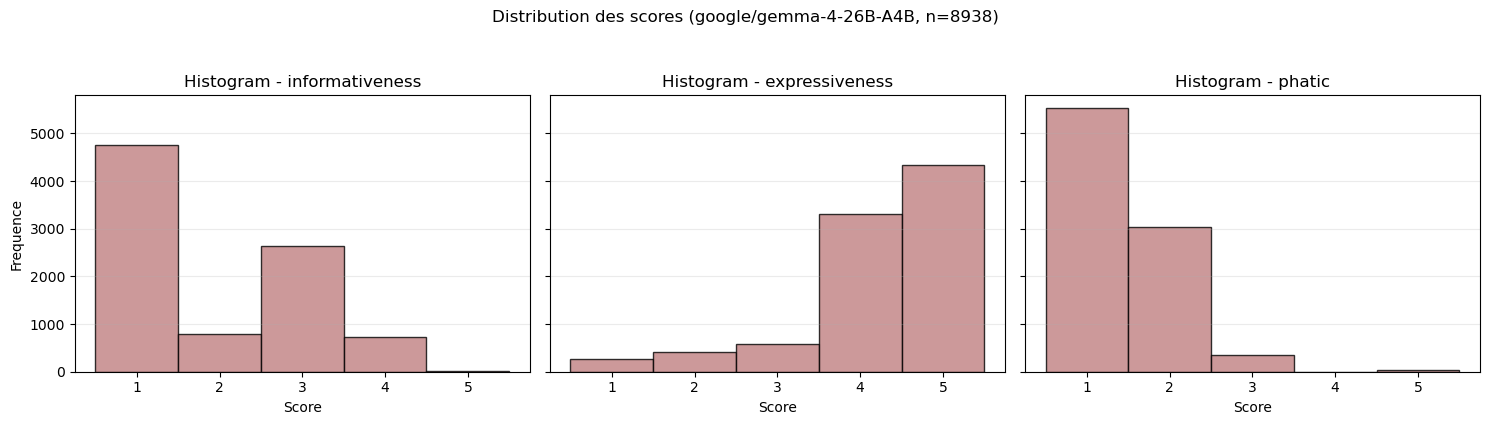

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

score_cols = ["informativeness", "expressiveness", "phatic"]
plot_df = scores_df.copy()
for col in score_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
for ax, col in zip(axes, score_cols):
    values = plot_df[col].dropna()
    ax.hist(values, bins=bins, edgecolor="black", alpha=0.8, color="#C08081")
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel("Score")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Frequence")
fig.suptitle(f"Distribution des scores ({MODEL_NAME}, n={len(plot_df)})", y=1.05)

hist_plot_path = PROJECT_ROOT / "latex" / "scores_hist_8938.png"
fig.savefig(hist_plot_path, dpi=200, bbox_inches="tight")
print("Saved histogram plot:", hist_plot_path)

plt.tight_layout()
plt.show()

## 8) Matrice de corrélation des scores

Calcul de la corrélation de Pearson entre `informativeness`, `expressiveness` et `phatic`.

Correlation matrix (Pearson):


,informativeness,expressiveness,phatic
informativeness,1.000,-0.626,0.590
expressiveness,-0.626,1.000,-0.241
phatic,0.590,-0.241,1.000


Saved correlation plot: /home/cbenavent/test/Arcom_rares/latex/scores_corr_8938.png


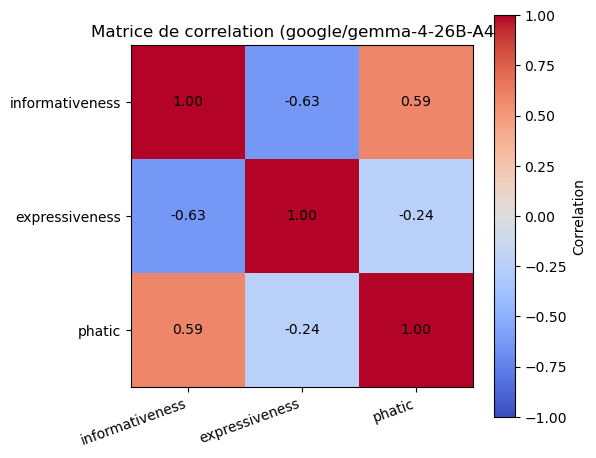

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

if "plot_df" in globals() and not plot_df.empty:
    corr_source = plot_df.copy()
elif "scores_df" in globals() and not scores_df.empty:
    corr_source = scores_df.copy()
else:
    corr_source = pd.read_csv(csv_scores_path)

score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    corr_source[col] = pd.to_numeric(corr_source[col], errors="coerce")

corr_df = corr_source[score_cols].corr(method="pearson")
print("Correlation matrix (Pearson):")
display(corr_df.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")
ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(score_cols)))
ax.set_xticklabels(score_cols, rotation=20, ha="right")
ax.set_yticklabels(score_cols)
ax.set_title(f"Matrice de correlation ({MODEL_NAME})")
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        value = corr_df.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

corr_plot_path = PROJECT_ROOT / "latex" / "scores_corr_8938.png"
fig.savefig(corr_plot_path, dpi=200, bbox_inches="tight")
print("Saved correlation plot:", corr_plot_path)

plt.tight_layout()
plt.show()

## 9) Evolution annuelle des scores

Section dédiée à l'évolution temporelle des trois dimensions `informativeness`, `expressiveness` et `phatic`.

Le graphe ci-dessous compare les scores moyens année par année sur l'ensemble des publicités annotées. L'échelle verticale est resserrée sur l'intervalle `1-3` pour mieux faire apparaître les écarts entre séries.

,year,informativeness,expressiveness,phatic
0,2014,1.659091,4.230519,1.227273
1,2015,1.801136,4.318182,1.333333
2,2016,1.951909,4.214993,1.496464
3,2017,1.817236,4.361070,1.317979
4,2018,1.881379,4.320000,1.388966
5,2019,1.820055,4.307692,1.394231
6,2020,1.919440,4.029772,1.401051
7,2021,2.020040,4.218437,1.482966
8,2022,2.070815,4.211373,1.586910
9,2023,2.008820,4.276798,1.540027


Saved yearly trend plot: /home/cbenavent/test/Arcom_rares/latex/scores_trend_yearly_8938.png


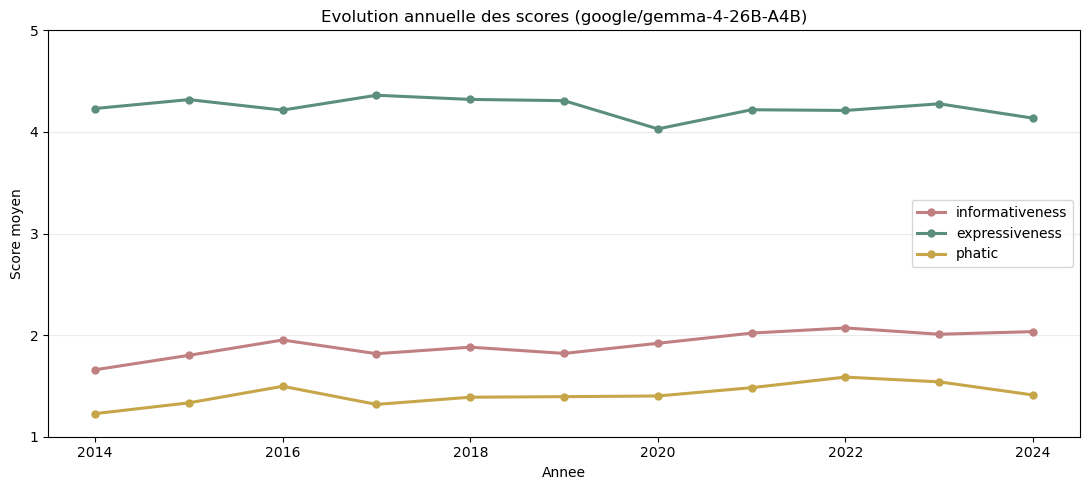

In [36]:
# --- Evolution annuelle des scores ---
import matplotlib.pyplot as plt
import pandas as pd

if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

year_source = df.loc[:, ["row_id", "year"]].copy()
year_source["year"] = pd.to_numeric(year_source["year"], errors="coerce")

yearly_scores_df = scores_df.merge(year_source, on="row_id", how="left")
score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    yearly_scores_df[col] = pd.to_numeric(yearly_scores_df[col], errors="coerce")

yearly_scores_df = yearly_scores_df.dropna(subset=["year"])
yearly_scores_df["year"] = yearly_scores_df["year"].astype(int)

yearly_trends_df = (
    yearly_scores_df
    .groupby("year", as_index=False)[score_cols]
    .mean()
    .sort_values("year")
)

display(yearly_trends_df.head(20))

fig, ax = plt.subplots(figsize=(11, 5))
colors = {
    "informativeness": "#C08081",
    "expressiveness": "#5B8E7D",
    "phatic": "#C7A64A",
}

for col in score_cols:
    ax.plot(
        yearly_trends_df["year"],
        yearly_trends_df[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=col,
        color=colors[col],
    )

ax.set_title(f"Evolution annuelle des scores ({MODEL_NAME})")
ax.set_xlabel("Annee")
ax.set_ylabel("Score moyen")
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(True, axis="y", alpha=0.25)
ax.legend()

trend_plot_path = PROJECT_ROOT / "latex" / "scores_trend_yearly_8938.png"
fig.savefig(trend_plot_path, dpi=200, bbox_inches="tight")
print("Saved yearly trend plot:", trend_plot_path)

plt.tight_layout()
plt.show()

## 10) Comparaison des scores pour les 10 marques les plus fréquentes

Section dédiée à la comparaison des scores moyens `informativeness`, `expressiveness` et `phatic` pour les 10 marques les plus représentées dans le corpus annoté.

Le graphe ci-dessous compare les moyennes par marque avec une échelle verticale resserrée sur l'intervalle `1-3`.

,Marque,informativeness,expressiveness,phatic
4,RENAULT,1.977011,4.011494,1.313218
2,FIAT 500,2.076364,4.203636,1.607273
0,CITROEN C3,1.346939,4.489796,1.065306
3,PEUGEOT 208,1.697674,4.265116,1.516279
8,TOYOTA YARIS,2.104167,4.192708,1.369792
9,VW,1.306011,4.349727,1.278689
6,RENAULT MEGANE,1.895062,4.444444,1.339506
5,RENAULT CLIO,2.000000,4.202614,2.078431
7,RENAULT ZOE,2.202703,3.527027,1.432432
1,DACIA SANDERO,1.460432,4.726619,1.223022


Saved top brands plot: /home/cbenavent/test/Arcom_rares/latex/scores_top_brands_8938.png


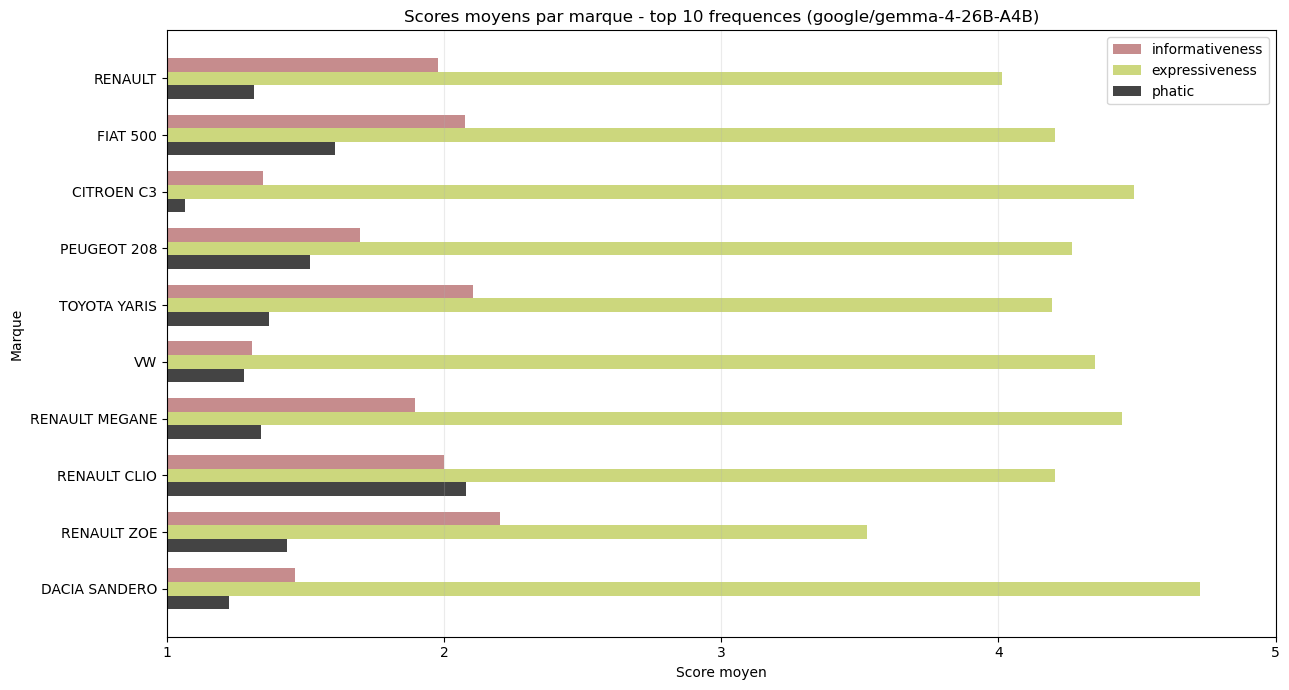

In [37]:
# --- Comparaison des scores pour les 10 marques les plus frequentes ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

brand_source = df.loc[:, ["row_id", "Marque"]].copy()
brand_source["Marque"] = brand_source["Marque"].astype(str).str.strip()
brand_source.loc[brand_source["Marque"].isin(["", "nan", "None"]), "Marque"] = pd.NA

brand_scores_df = scores_df.merge(brand_source, on="row_id", how="left")
score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    brand_scores_df[col] = pd.to_numeric(brand_scores_df[col], errors="coerce")

brand_scores_df = brand_scores_df.dropna(subset=["Marque"])
top_brands = brand_scores_df["Marque"].value_counts().head(10).index.tolist()
brand_scores_df = brand_scores_df[brand_scores_df["Marque"].isin(top_brands)].copy()

brand_trends_df = (
    brand_scores_df
    .groupby("Marque", as_index=False)[score_cols]
    .mean()
)
brand_trends_df["brand_rank"] = pd.Categorical(brand_trends_df["Marque"], categories=top_brands, ordered=True)
brand_trends_df = brand_trends_df.sort_values("brand_rank").drop(columns=["brand_rank"])

display(brand_trends_df)

fig, ax = plt.subplots(figsize=(13, 7))
colors = {
    "informativeness": "#C08081",
    "expressiveness": "#C7D36F",
    "phatic": "#2F2F2F",
}

y = np.arange(len(brand_trends_df))
bar_height = 0.24
offsets = {
    "informativeness": -bar_height,
    "expressiveness": 0.0,
    "phatic": bar_height,
}

for col in score_cols:
    ax.barh(
        y + offsets[col],
        brand_trends_df[col],
        height=bar_height,
        label=col,
        color=colors[col],
        alpha=0.9,
    )

ax.set_title(f"Scores moyens par marque - top 10 frequences ({MODEL_NAME})")
ax.set_xlabel("Score moyen")
ax.set_ylabel("Marque")
ax.set_xlim(1, 5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks(y)
ax.set_yticklabels(brand_trends_df["Marque"])
ax.grid(True, axis="x", alpha=0.25)
ax.legend()
ax.invert_yaxis()

brand_plot_path = PROJECT_ROOT / "latex" / "scores_top_brands_8938.png"
fig.savefig(brand_plot_path, dpi=200, bbox_inches="tight")
print("Saved top brands plot:", brand_plot_path)

plt.tight_layout()
plt.show()

In [38]:
# Export only successfully annotated rows to CSV
import pandas as pd
from pathlib import Path

# all_results is created in your execution cell
results_df = pd.DataFrame(all_results)

# Keep only rows where annotation parsing succeeded
ok_df = results_df[results_df["parse_ok"] == True].copy()

# Flatten prediction dict columns
pred_cols = pd.json_normalize(ok_df["prediction"])
pred_cols.columns = [f"pred_{c}" for c in pred_cols.columns]
ok_df = pd.concat([ok_df.drop(columns=["prediction"]), pred_cols], axis=1)

# Optional: join with original dataset columns (e.g., year, Marque, etc.)
source_df = pd.read_csv(DATASET_PATH)
annotated_rows_df = ok_df.merge(source_df, on="row_id", how="left")

# Save
annotated_csv_path = OUTPUT_DIR / "annotated_rows_only.csv"
annotated_rows_df.to_csv(annotated_csv_path, index=False)

print(f"Saved: {annotated_csv_path}")
print(f"Annotated rows: {len(annotated_rows_df)} / {len(results_df)}")
display(annotated_rows_df.head(10))

Saved: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/annotated_rows_only.csv
Annotated rows: 8938 / 8938


,row_id,visuel,model_name,raw_output,parse_ok,parse_error,pred_informativeness,pred_expressiveness,pred_phatic,pred_dominant_dimension,...,Agence,Month,Electric,Hybrid,length,n,Annonceur2,Main_Benefit,Secondary_Benefit,Review_Status
0,0,"En caméra cachée, un homme invite des personne...",google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,NaN,1,0,0,141,1426,RENAULT,Design/Emotion,Innovation/Technology,needs_label
1,1,Un homme recharge sa NISSAN LEAF et traverse u...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 3,\n ""expressiveness""...",True,,3,4,2,expressiveness,...,TBWA,1,1,0,165,343,NISSAN AUTOMOBILES,Electrification,Price/Value,needs_label
2,2,Des journalistes interrogent un homme qui vien...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,LES GAULOIS,1,0,0,342,815,CITROEN,Price/Value,Comfort/Practicality,needs_label
3,3,Des journalistes interrogent un homme qui vien...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,LES GAULOIS,1,0,0,342,815,CITROEN,Price/Value,Comfort/Practicality,needs_label
4,4,Des journalistes interrogent un homme qui vien...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,LES GAULOIS,1,0,0,341,815,CITROEN,Price/Value,Comfort/Practicality,needs_label
5,5,FORD B-MAX > Easy access**. **Portes arrière c...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 4,\n ""expressiveness""...",True,,4,2,1,informativeness,...,OGILVY & MATHER,1,0,0,96,229,FORD,Price/Value,NaN,needs_label
6,6,"Dans un restaurant, un homme et une femme inco...",google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,INNOCEAN WORLDWIDE FRANCE,1,0,0,170,218,KIA,Innovation/Technology,Price/Value,needs_label
7,7,"Dans les gradins d'un court de tennis, une fem...",google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,INNOCEAN WORLDWIDE FRANCE,1,0,0,170,218,KIA,Price/Value,Comfort/Practicality,needs_label
8,8,Vision du monde en 2050 où les nouvelles techn...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,SAATCHI & SAATCHI,1,0,1,164,498,TOYOTA,Innovation/Technology,Electrification,needs_label
9,9,Vision du monde en 2050 où les nouvelles techn...,google/gemma-4-26B-A4B,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,5,1,expressiveness,...,SAATCHI & SAATCHI,1,0,1,164,498,TOYOTA,Innovation/Technology,Electrification,needs_label
